# ECG Arrhythmia Classification: EDA

This notebook checks the raw Kaggle heartbeat files, confirms the MIT-BIH multiclass label structure, and creates the first dataset plots used in the report.

In [24]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src import config
from src.data.load_data import load_mitbih
from src.data.validate_data import build_class_distribution, summarize_csv
from src.visualization.eda_plots import (
    save_class_counts,
    save_examples_per_class,
    save_mean_waveforms,
)

LABEL_NAMES = {
    0: "N: normal beat",
    1: "S: supraventricular ectopic beat",
    2: "V: ventricular ectopic beat",
    3: "F: fusion beat",
    4: "Q: unknown beat",
}

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")
sns.set_theme(style="whitegrid", context="notebook")

## Raw files

In [25]:
raw_csvs = sorted(config.RAW_DATA_DIR.glob("*.csv"))
raw_summary = pd.DataFrame([summarize_csv(path) for path in raw_csvs]).fillna(0)
raw_summary

,file,rows,columns,feature_columns,missing_values,min_label,max_label,n_classes,class_0,class_1,class_2,class_3,class_4
0,mitbih_test.csv,21892,188,187,0,0,4,5,18118.0000,556.0000,1448.0000,162.0000,1608.0000
1,mitbih_train.csv,87554,188,187,0,0,4,5,72471.0000,2223.0000,5788.0000,641.0000,6431.0000
2,ptbdb_abnormal.csv,10506,188,187,0,1,1,1,0.0000,10506.0000,0.0000,0.0000,0.0000
3,ptbdb_normal.csv,4046,188,187,0,0,0,1,4046.0000,0.0000,0.0000,0.0000,0.0000


## Dataset preview and structure

The raw files contain one heartbeat per row. The first 187 columns are time-ordered waveform samples and the final column is the class label. The preview below shows the original table before any splitting, filtering, or feature extraction.

In [26]:
preview_df = pd.read_csv(config.MITBIH_TRAIN_CSV, header=None, nrows=5)
preview_df = preview_df.rename(columns={187: "label"})

print(f"Preview shape: {preview_df.shape}")
display(preview_df.iloc[:, :10])
display(preview_df[["label"]])

Preview shape: (5, 188)


,0,1,2,3,4,5,6,7,8,9
0,0.9779,0.9265,0.6814,0.2451,0.1544,0.1912,0.1520,0.0858,0.0588,0.0490
1,0.9601,0.8632,0.4615,0.1966,0.0940,0.1254,0.0997,0.0883,0.0741,0.0826
2,1.0000,0.6595,0.1865,0.0703,0.0703,0.0595,0.0568,0.0432,0.0541,0.0459
3,0.9254,0.6657,0.5414,0.2762,0.1961,0.0773,0.0718,0.0608,0.0663,0.0580
4,0.9671,1.0000,0.8310,0.5869,0.3568,0.2488,0.1455,0.0892,0.1174,0.1502


,label
0,0.0000
1,0.0000
2,0.0000
3,0.0000
4,0.0000


MIT-BIH is the 5-class task used in this project. PTBDB is present in the Kaggle download, but it is a separate binary normal/abnormal dataset and is not merged into the MIT-BIH classifier.

## MIT-BIH shape and labels

In [27]:
x_train_full, y_train_full, x_test, y_test = load_mitbih()

shape_summary = pd.DataFrame(
    [
        {"split": "train", "rows": x_train_full.shape[0], "time_steps": x_train_full.shape[1]},
        {"split": "test", "rows": x_test.shape[0], "time_steps": x_test.shape[1]},
    ]
)
shape_summary

,split,rows,time_steps
0,train,87554,187
1,test,21892,187


## Dataset integrity checks

These checks look for structural problems before modeling: missing or non-finite values, duplicate rounded waveforms, flat segments, and unexpected labels.

In [28]:
quality_rows = []
for split_name, x, y in [
    ("train", x_train_full, y_train_full),
    ("test", x_test, y_test),
]:
    row_std = x.std(axis=1)
    rounded_rows = np.round(x, 6)
    unique_rows = np.unique(rounded_rows, axis=0).shape[0]
    quality_rows.append(
        {
            "split": split_name,
            "rows": len(y),
            "waveform_samples": x.shape[1],
            "finite_waveform_values": bool(np.isfinite(x).all()),
            "finite_labels": bool(np.isfinite(y).all()),
            "missing_waveform_values": int(np.isnan(x).sum()),
            "duplicate_waveforms_rounded_6dp": int(len(y) - unique_rows),
            "flat_waveforms": int(np.sum(row_std == 0.0)),
            "label_values": sorted(np.unique(y).astype(int).tolist()),
        }
    )

quality_summary = pd.DataFrame(quality_rows)
quality_summary

,split,rows,waveform_samples,finite_waveform_values,finite_labels,missing_waveform_values,duplicate_waveforms_rounded_6dp,flat_waveforms,label_values
0,train,87554,187,True,True,0,0,0,"[0, 1, 2, 3, 4]"
1,test,21892,187,True,True,0,0,0,"[0, 1, 2, 3, 4]"


In [29]:
class_distribution = build_class_distribution(y_train_full, y_test)
class_distribution

,class,train_count,train_fraction,test_count,test_fraction
0,0,72471,0.8277,18118,0.8276
1,1,2223,0.0254,556,0.0254
2,2,5788,0.0661,1448,0.0661
3,3,641,0.0073,162,0.0074
4,4,6431,0.0735,1608,0.0735


## Label semantics and class balance

The numeric labels are dataset codes, not continuous values. The table below attaches the rhythm meaning to each code and shows why balanced metrics are required.

In [30]:
label_table = class_distribution.copy()
label_table["class_name"] = label_table["class"].map(LABEL_NAMES)
label_table = label_table[
    ["class", "class_name", "train_count", "train_fraction", "test_count", "test_fraction"]
]
label_table

,class,class_name,train_count,train_fraction,test_count,test_fraction
0,0,N: normal beat,72471,0.8277,18118,0.8276
1,1,S: supraventricular ectopic beat,2223,0.0254,556,0.0254
2,2,V: ventricular ectopic beat,5788,0.0661,1448,0.0661
3,3,F: fusion beat,641,0.0073,162,0.0074
4,4,Q: unknown beat,6431,0.0735,1608,0.0735


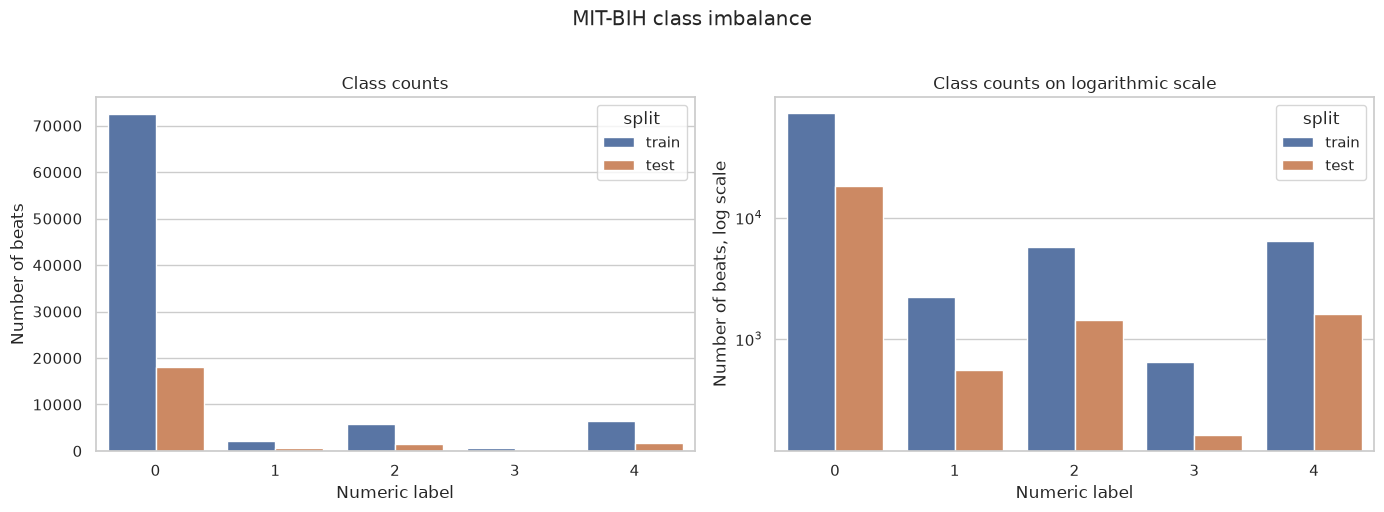

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_data = label_table.melt(
    id_vars=["class", "class_name"],
    value_vars=["train_count", "test_count"],
    var_name="split",
    value_name="count",
)
plot_data["split"] = plot_data["split"].str.replace("_count", "", regex=False)
sns.barplot(data=plot_data, x="class", y="count", hue="split", ax=axes[0])
axes[0].set_title("Class counts")
axes[0].set_xlabel("Numeric label")
axes[0].set_ylabel("Number of beats")

sns.barplot(data=plot_data, x="class", y="count", hue="split", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Class counts on logarithmic scale")
axes[1].set_xlabel("Numeric label")
axes[1].set_ylabel("Number of beats, log scale")
fig.suptitle("MIT-BIH class imbalance", y=1.02)
fig.tight_layout()
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(config.FIGURES_DIR / "mitbih_class_imbalance_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

The class distribution is heavily skewed toward class 0. Accuracy will be a weak metric by itself, so the project uses macro F1 and per-class precision/recall/F1 as primary evaluation evidence.

## Waveform ranges

In [32]:
waveform_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "min": float(x_train_full.min()),
            "max": float(x_train_full.max()),
            "mean": float(x_train_full.mean()),
            "std": float(x_train_full.std()),
            "zero_fraction": float(np.mean(x_train_full == 0.0)),
        },
        {
            "split": "test",
            "min": float(x_test.min()),
            "max": float(x_test.max()),
            "mean": float(x_test.mean()),
            "std": float(x_test.std()),
            "zero_fraction": float(np.mean(x_test == 0.0)),
        },
    ]
)
waveform_summary

,split,min,max,mean,std,zero_fraction
0,train,0.0000,1.0000,0.1743,0.2263,0.4085
1,test,0.0000,1.0000,0.1735,0.2256,0.4099


## Derived waveform features

Before the production feature extractor runs, these simple per-beat summaries make the raw data easier to understand. They describe amplitude, variation, energy, and the amount of exact-zero content by label.

In [33]:
def summarize_beats(x, y, split_name):
    differences = np.diff(x, axis=1)
    return pd.DataFrame(
        {
            "split": split_name,
            "label": y.astype(int),
            "class_name": pd.Series(y.astype(int)).map(LABEL_NAMES).to_numpy(),
            "mean": x.mean(axis=1),
            "std": x.std(axis=1),
            "minimum": x.min(axis=1),
            "maximum": x.max(axis=1),
            "range": np.ptp(x, axis=1),
            "energy": np.sum(x**2, axis=1),
            "mean_abs_change": np.mean(np.abs(differences), axis=1),
            "zero_fraction": np.mean(x == 0.0, axis=1),
        }
    )

beat_summary = pd.concat(
    [
        summarize_beats(x_train_full, y_train_full, "train"),
        summarize_beats(x_test, y_test, "test"),
    ],
    ignore_index=True,
)

feature_by_class = (
    beat_summary[beat_summary["split"] == "train"]
    .groupby(["label", "class_name"])[
        ["mean", "std", "range", "energy", "mean_abs_change", "zero_fraction"]
    ]
    .agg(["mean", "std"])
    .round(4)
)
feature_by_class

mean           std         range  \
                                         mean    std   mean    std   mean   
label class_name                                                            
0     N: normal beat                   0.1619 0.1020 0.1861 0.0477 1.0000   
1     S: supraventricular ectopic beat 0.1948 0.0886 0.1868 0.0577 0.9908   
2     V: ventricular ectopic beat      0.2438 0.1095 0.2290 0.0662 0.9995   
3     F: fusion beat                   0.1073 0.0585 0.1813 0.0314 1.0000   
4     Q: unknown beat                  0.2509 0.0896 0.2412 0.0605 1.0000   

                                               energy         mean_abs_change  \
                                          std    mean     std            mean   
label class_name                                                                
0     N: normal beat                   0.0026 13.7527 13.5399          0.0233   
1     S: supraventricular ectopic beat 0.0396 15.7089  8.9644          0.0247   
2     V: ventricular ectopic beat      0.0119 23.9895 15.9009          0.0189   
3     F: fusion beat                   0.0006  9.1202  8.9216          0.0175   
4     Q: unknown beat                  0.0000 24.8311 13.6132          0.0236   

                                              zero_fraction         
                                          std          mean    std  
label class_name                                                    
0     N: normal beat                   0.0056        0.4132 0.1452  
1     S: supraventricular ectopic beat 0.0058        0.3964 0.2100  
2     V: ventricular ectopic beat      0.0041        0.3738 0.1866  
3     F: fusion beat                   0.0034        0.5830 0.0740  
4     Q: unknown beat                  0.0053        0.3732 0.0521

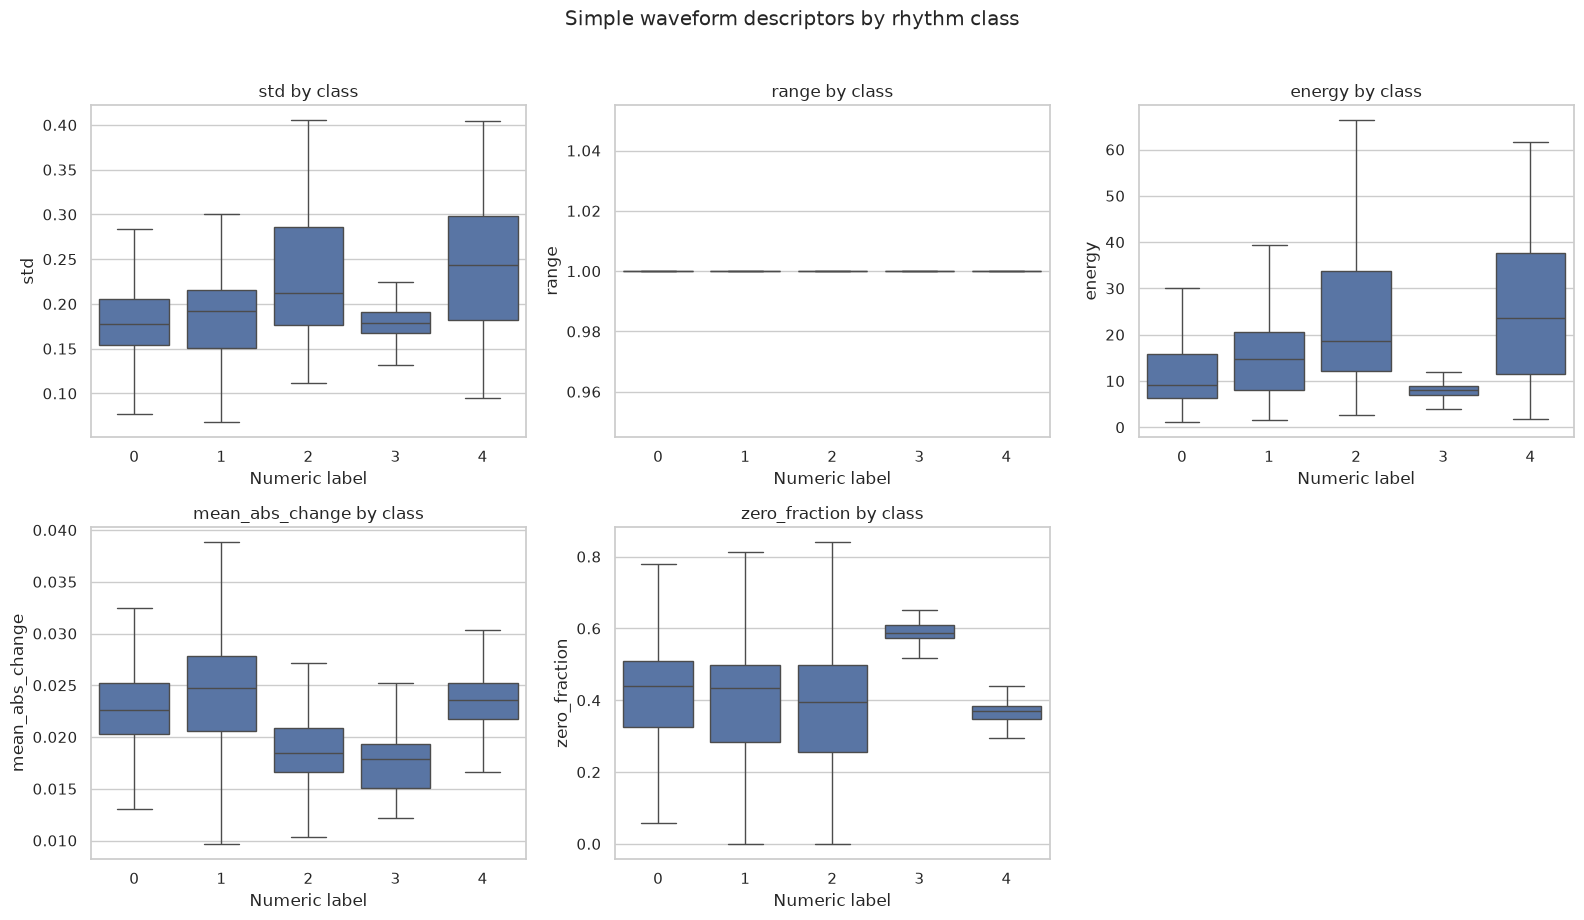

In [34]:
feature_columns = ["std", "range", "energy", "mean_abs_change", "zero_fraction"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feature_name in zip(axes.flat, feature_columns):
    sns.boxplot(
        data=beat_summary[beat_summary["split"] == "train"],
        x="label",
        y=feature_name,
        ax=ax,
        showfliers=False,
    )
    ax.set_title(f"{feature_name} by class")
    ax.set_xlabel("Numeric label")
    ax.set_ylabel(feature_name)
axes.flat[-1].axis("off")
fig.suptitle("Simple waveform descriptors by rhythm class", y=1.02)
fig.tight_layout()
plt.show()

The segments are already scaled to [0, 1]. The large zero fraction is expected from padded or low-amplitude portions of the fixed-length beats. For model inputs, we keep the raw scaled arrays and also prepare per-beat z-score arrays for comparisons.

## EDA plots

In [35]:
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

class_counts_path = config.FIGURES_DIR / "mitbih_class_counts.png"
examples_path = config.FIGURES_DIR / "mitbih_examples_per_class.png"
means_path = config.FIGURES_DIR / "mitbih_mean_waveforms.png"

save_class_counts(y_train_full, y_test, class_counts_path)
save_examples_per_class(x_train_full, y_train_full, examples_path)
save_mean_waveforms(x_train_full, y_train_full, means_path)

[class_counts_path, examples_path, means_path]

[PosixPath('/home/shubham/Desktop/ML-Projects/Project_01/reports/figures/mitbih_class_counts.png'),
 PosixPath('/home/shubham/Desktop/ML-Projects/Project_01/reports/figures/mitbih_examples_per_class.png'),
 PosixPath('/home/shubham/Desktop/ML-Projects/Project_01/reports/figures/mitbih_mean_waveforms.png')]

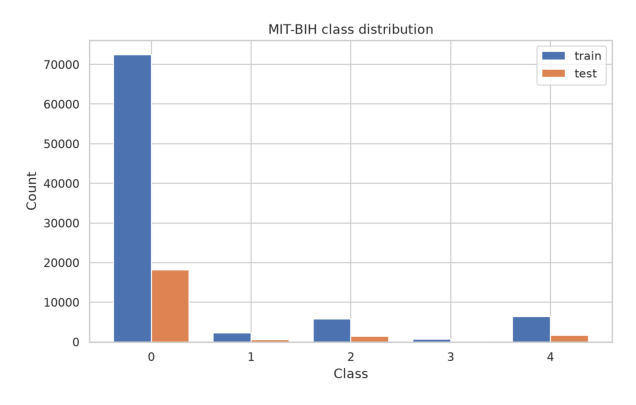

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
img = plt.imread(class_counts_path)
ax.imshow(img)
ax.axis("off");

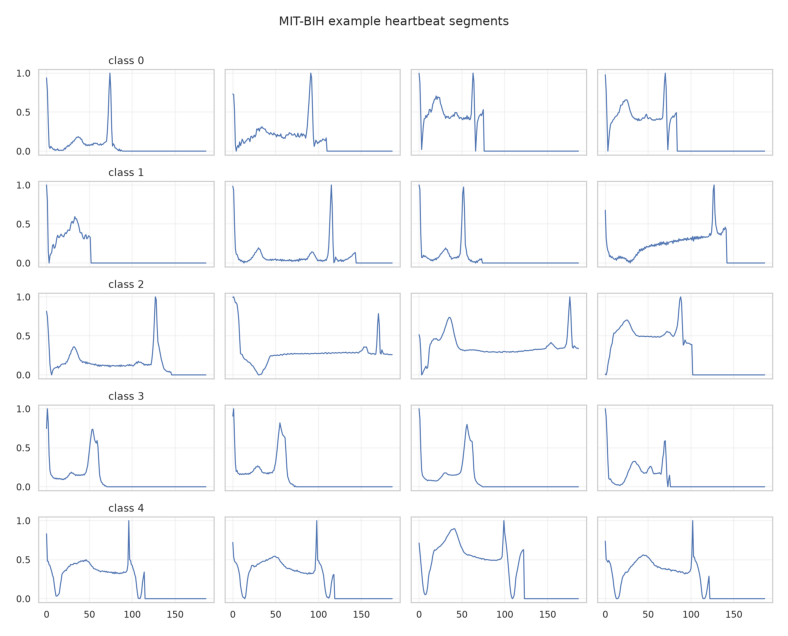

In [37]:
fig, ax = plt.subplots(figsize=(12, 8))
img = plt.imread(examples_path)
ax.imshow(img)
ax.axis("off");

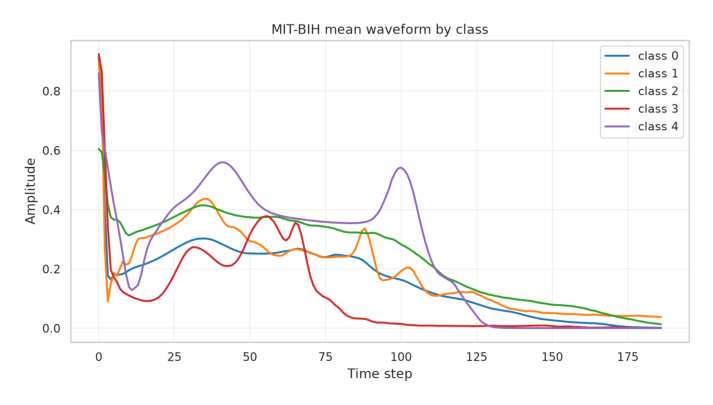

In [38]:
fig, ax = plt.subplots(figsize=(9, 5))
img = plt.imread(means_path)
ax.imshow(img)
ax.axis("off");

## Additional graphical understanding

The next plots show variation within each class and make it easier to see whether the labels correspond to visibly different waveform families. These are descriptive plots only; they are not model validation.

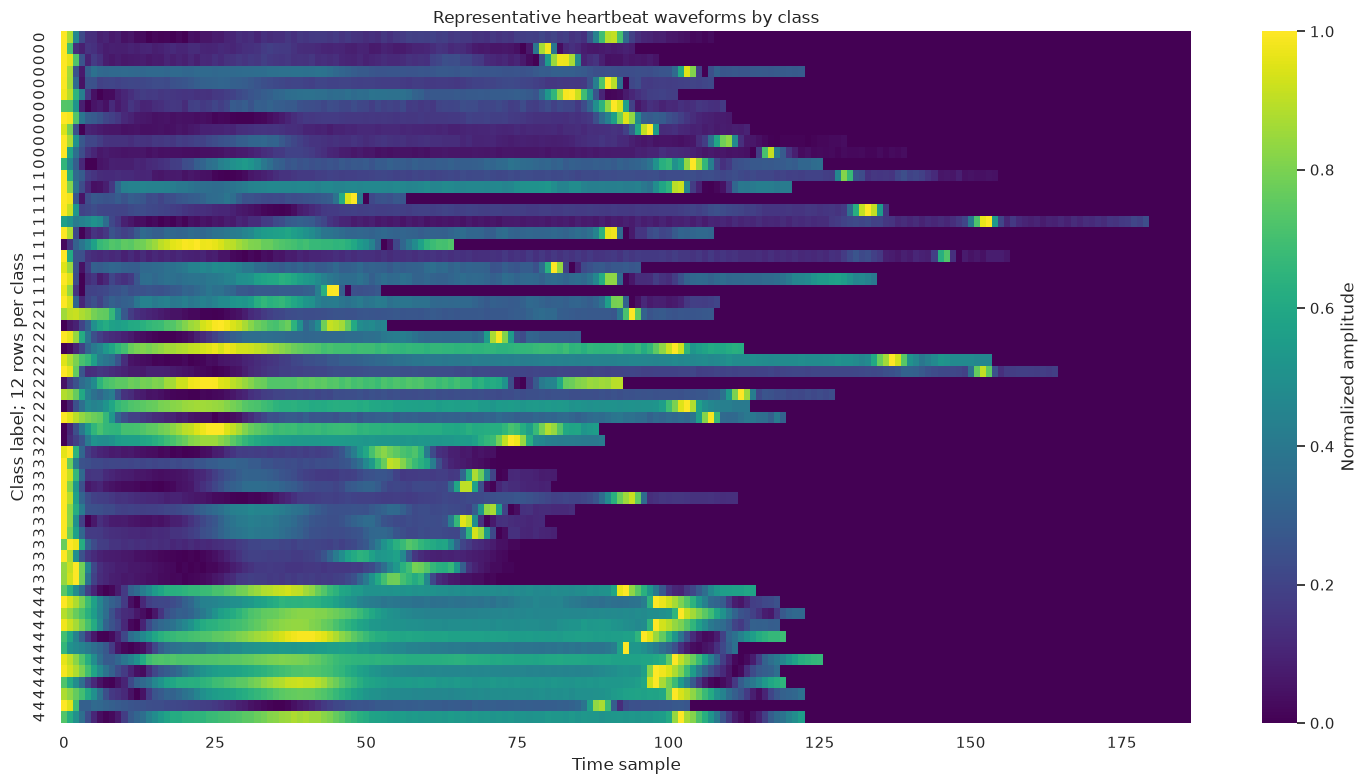

In [39]:
rng = np.random.default_rng(config.RANDOM_SEED)
selected_waveforms = []
selected_labels = []
for label in sorted(np.unique(y_train_full).astype(int)):
    label_indices = np.flatnonzero(y_train_full == label)
    chosen_indices = rng.choice(label_indices, size=min(12, len(label_indices)), replace=False)
    selected_waveforms.append(x_train_full[chosen_indices])
    selected_labels.extend([label] * len(chosen_indices))

heatmap_waveforms = np.vstack(selected_waveforms)
fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(
    heatmap_waveforms,
    cmap="viridis",
    xticklabels=25,
    yticklabels=selected_labels,
    ax=ax,
    cbar_kws={"label": "Normalized amplitude"},
)
ax.set_title("Representative heartbeat waveforms by class")
ax.set_xlabel("Time sample")
ax.set_ylabel("Class label; 12 rows per class")
plt.tight_layout()
plt.show()

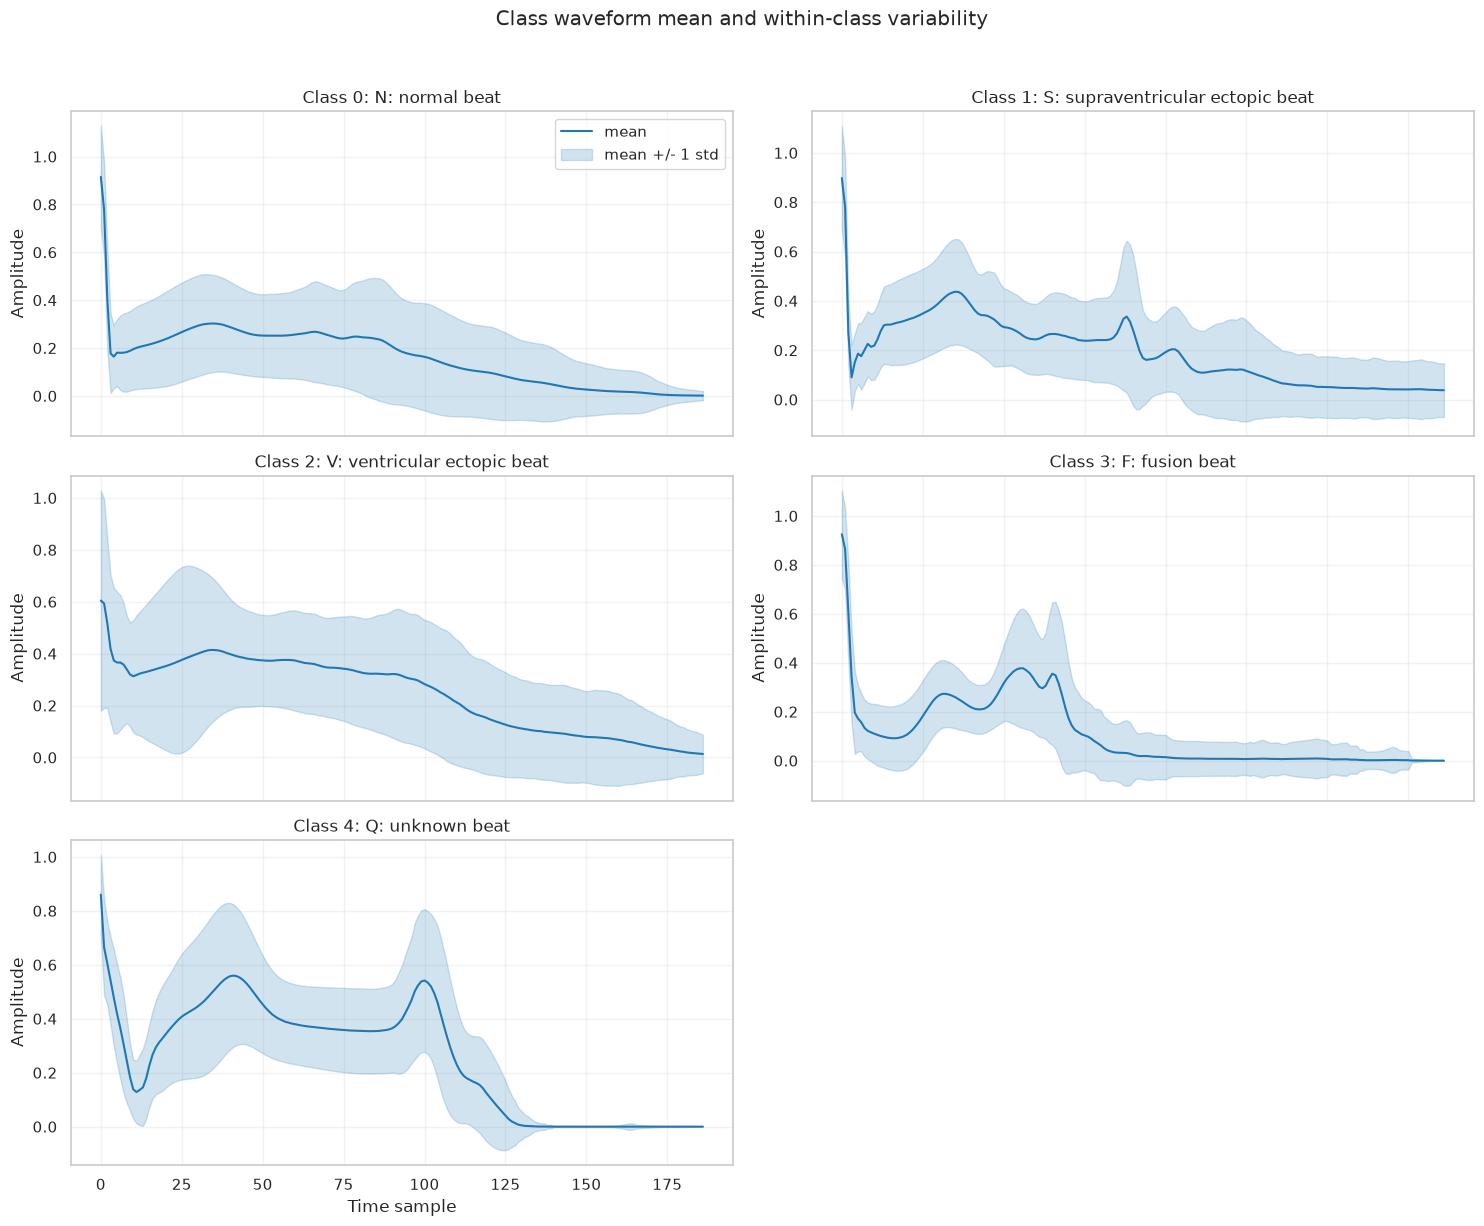

In [40]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
for ax, label in zip(axes.flat, sorted(np.unique(y_train_full).astype(int))):
    class_waveforms = x_train_full[y_train_full == label]
    mean_waveform = class_waveforms.mean(axis=0)
    std_waveform = class_waveforms.std(axis=0)
    time = np.arange(x_train_full.shape[1])
    ax.plot(time, mean_waveform, color="tab:blue", label="mean")
    ax.fill_between(
        time,
        mean_waveform - std_waveform,
        mean_waveform + std_waveform,
        color="tab:blue",
        alpha=0.2,
        label="mean +/- 1 std",
    )
    ax.set_title(f"Class {label}: {LABEL_NAMES[label]}")
    ax.set_ylabel("Amplitude")
    ax.grid(alpha=0.25)
axes[-1, 0].set_xlabel("Time sample")
axes[-1, 1].set_xlabel("Time sample")
axes.flat[-1].axis("off")
axes[0, 0].legend()
fig.suptitle("Class waveform mean and within-class variability", y=1.02)
fig.tight_layout()
plt.show()

## Feature relationships and train/test consistency

These summaries check whether simple waveform descriptors have visible relationships with one another and whether the two official splits have comparable distributions.

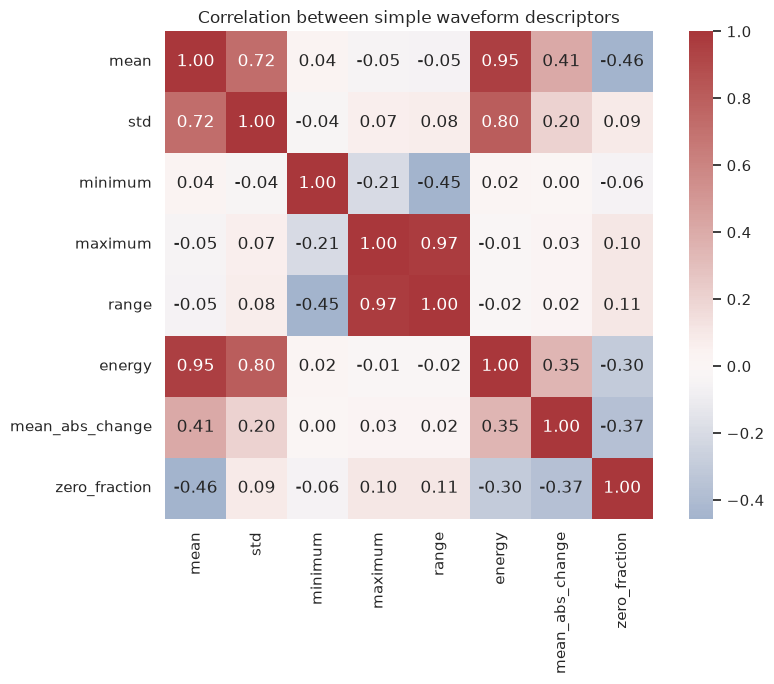

In [41]:
numeric_features = [
    "mean",
    "std",
    "minimum",
    "maximum",
    "range",
    "energy",
    "mean_abs_change",
    "zero_fraction",
]

correlation_matrix = beat_summary[numeric_features].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
    ax=ax,
)
ax.set_title("Correlation between simple waveform descriptors")
plt.tight_layout()
plt.show()

In [42]:
split_feature_summary = (
    beat_summary.groupby("split")[numeric_features]
    .agg(["mean", "std"])
    .T.round(4)
)
split_feature_summary

split                   test   train
mean            mean  0.1735  0.1743
                std   0.1043  0.1056
std             mean  0.1929  0.1930
                std   0.0527  0.0532
minimum         mean  0.0000  0.0000
                std   0.0016  0.0019
maximum         mean  0.9998  0.9997
                std   0.0050  0.0069
range           mean  0.9998  0.9997
                std   0.0055  0.0075
energy          mean 15.1412 15.2589
                std  13.8695 14.0932
mean_abs_change mean  0.0230  0.0230
                std   0.0055  0.0057
zero_fraction   mean  0.4099  0.4085
                std   0.1466  0.1467

## Decisions for the next stage

1. Use MIT-BIH only for the 5-class heartbeat classifier.
2. Keep the Kaggle test split untouched until final evaluation.
3. Use a stratified validation split from `mitbih_train.csv` for model selection.
4. Save both raw scaled waveforms and per-beat z-score waveforms.
5. Use macro F1 as the main metric because class 3 is extremely rare.